In [ ]:
from two_tower_confounding.models.towers import *
from two_tower_confounding.metrics import NDCG, MRR, NegativeLogLikelihood
from two_tower_confounding.models.two_tower import TwoTowerModel
from two_tower_confounding.simulation.simulator import Simulator
from two_tower_confounding.trainer import Trainer
from two_tower_confounding.utils import np_collate

In [ ]:
# load: two-tower-confounding/results/test/test_datasets/test_click_dataset_policy_temperature0.0_sdoc0.0_num_queries1_.pkl

import pickle as pkl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import two_tower_confounding as ttc

with open('results/test/test_datasets/test_click_dataset_policy_temperature0.0_sdoc0.0_num_queries1_.pkl', 'rb') as f:
    click_data = pkl.load(f)
with open('results/test/test_datasets/test_click_dataset_policy_temperature1.0_sdoc0.0_num_queries1_.pkl', 'rb') as f:
    click_data_tmp_1 = pkl.load(f)


In [ ]:
df = pd.DataFrame(list(click_data))
df_tmp_1 = pd.DataFrame(list(click_data_tmp_1))

In [ ]:
df_tmp_1

In [24]:
df.query_doc_ids = df.query_doc_ids.apply(lambda x: tuple(x))
df.query_doc_ids.unique()

array([(np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10))],
      dtype=object)

In [25]:
df

,query,query_doc_features,query_doc_ids,labels,propensities,clicks,positions,mask,n
0,0,"[[0.0, 1.741676], [0.0, 1.5654233], [0.0, 1.52...","(1, 2, 3, 4, 5, 6, 7, 8, 9, 10)","[0.0, 0.2965051492107924, 0.4196948181788126, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0, 0, 0, 0, 0, 0, 1, 0, 0, 0]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]","[True, True, True, True, True, True, True, Tru...",10
1,0,"[[0.0, 1.741676], [0.0, 1.5654233], [0.0, 1.52...","(1, 2, 3, 4, 5, 6, 7, 8, 9, 10)","[0.0, 0.2965051492107924, 0.4196948181788126, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0, 0, 0, 0, 0, 0, 1, 0, 0, 1]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]","[True, True, True, True, True, True, True, Tru...",10
2,0,"[[0.0, 1.741676], [0.0, 1.5654233], [0.0, 1.52...","(1, 2, 3, 4, 5, 6, 7, 8, 9, 10)","[0.0, 0.2965051492107924, 0.4196948181788126, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]","[True, True, True, True, True, True, True, Tru...",10
3,0,"[[0.0, 1.741676], [0.0, 1.5654233], [0.0, 1.52...","(1, 2, 3, 4, 5, 6, 7, 8, 9, 10)","[0.0, 0.2965051492107924, 0.4196948181788126, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]","[True, True, True, True, True, True, True, Tru...",10
4,0,"[[0.0, 1.741676], [0.0, 1.5654233], [0.0, 1.52...","(1, 2, 3, 4, 5, 6, 7, 8, 9, 10)","[0.0, 0.2965051492107924, 0.4196948181788126, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0, 0, 0, 0, 0, 0, 1, 1, 1, 1]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]","[True, True, True, True, True, True, True, Tru...",10
...,...,...,...,...,...,...,...,...,...
49995,0,"[[0.0, 1.741676], [0.0, 1.5654233], [0.0, 1.52...","(1, 2, 3, 4, 5, 6, 7, 8, 9, 10)","[0.0, 0.2965051492107924, 0.4196948181788126, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0, 0, 0, 0, 0, 0, 0, 1, 0, 0]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]","[True, True, True, True, True, True, True, Tru...",10
49996,0,"[[0.0, 1.741676], [0.0, 1.5654233], [0.0, 1.52...","(1, 2, 3, 4, 5, 6, 7, 8, 9, 10)","[0.0, 0.2965051492107924, 0.4196948181788126, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 1, 0]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]","[True, True, True, True, True, True, True, Tru...",10
49997,0,"[[0.0, 1.741676], [0.0, 1.5654233], [0.0, 1.52...","(1, 2, 3, 4, 5, 6, 7, 8, 9, 10)","[0.0, 0.2965051492107924, 0.4196948181788126, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0, 0, 1, 0, 1, 0, 0, 1, 1, 1]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]","[True, True, True, True, True, True, True, Tru...",10
49998,0,"[[0.0, 1.741676], [0.0, 1.5654233], [0.0, 1.52...","(1, 2, 3, 4, 5, 6, 7, 8, 9, 10)","[0.0, 0.2965051492107924, 0.4196948181788126, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0, 0, 0, 0, 0, 0, 0, 1, 0, 0]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]","[True, True, True, True, True, True, True, Tru...",10


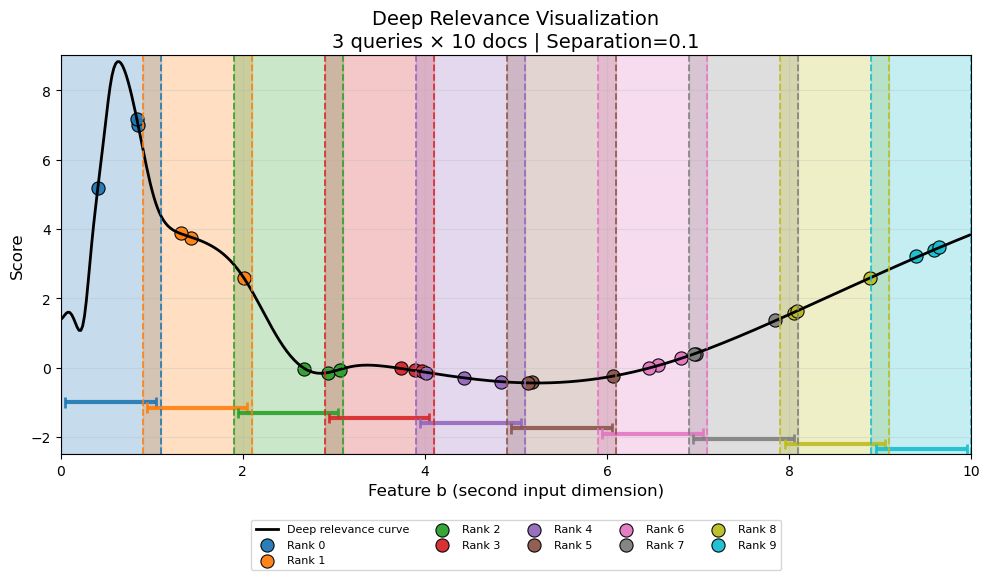

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# DeepRelevance Model Definition
# -------------------------------
class DeepRelevance:
    def __init__(self, hidden_units=[32, 32, 32], *, random_state: int, noise: float = 0.0):
        self.hidden_units = hidden_units
        self.noise = noise
        self.rng = np.random.default_rng(random_state)
        self.layers = []

    def __call__(self, query_document_features: np.ndarray) -> np.ndarray:
        n_docs, n_features = query_document_features.shape
        if not self.layers:
            input_size = n_features
            for units in self.hidden_units:
                W = self.rng.standard_normal((input_size, units))
                b = self.rng.standard_normal(units)
                self.layers.append((W, b))
                input_size = units
            W_out = self.rng.standard_normal(input_size)
            b_out = self.rng.standard_normal()
            self.output_layer = (W_out, b_out)

        hidden = query_document_features
        for (W, b) in self.layers:
            hidden = np.tanh(hidden.dot(W) + b)
        scores = hidden.dot(self.output_layer[0]) + self.output_layer[1]
        noise = self.noise * self.rng.standard_normal(scores.shape)
        return scores + noise


# ---------------------------------------------
# Data generation
# ---------------------------------------------
def generate_deep_score_and_features_overlap(
    num_queries, num_groups, docs_per_group, D, s_group, s_doc, rng, deep_model
):
    all_scores = []
    all_data = []
    boundaries = []

    for qid in range(num_queries):
        begin = 0.0
        end = 1.0
        q_boundaries = []

        for grp_idx in range(num_groups):
            for doc_idx in range(docs_per_group):
                a = 0.0
                if doc_idx == 0:
                    b = rng.uniform(begin, end + s_doc)
                    q_boundaries.append((begin, end + s_doc, doc_idx))
                elif doc_idx == docs_per_group - 1:
                    b = rng.uniform(begin - s_doc, end)
                    q_boundaries.append((begin - s_doc, end, doc_idx))
                else:
                    b = rng.uniform(begin - s_doc, end + s_doc)
                    q_boundaries.append((begin - s_doc, end + s_doc, doc_idx))

                features = np.array([[a, b]])
                score = deep_model(features)[0]
                all_scores.append(score)
                all_data.append((qid, grp_idx, doc_idx, [a, b]))

                begin += 1
                end += 1

        boundaries.append(q_boundaries)

    return np.array(all_scores), np.array(all_data, dtype=object), boundaries


# ---------------------------------------------
# Visualization function with baseline lines and vertical caps
# ---------------------------------------------
def visualize_deep_relevance_with_caps(
    num_queries=2,
    docs_per_group=10,
    s_doc=0.0,
    hidden_units=[32, 32, 32],
    noise=0.0,
    random_state=41,
    show_boundaries=True,
    show_fill=True,
    fill_cmap="tab10",
    point_cmap="tab10",
    seed=42,
    jitter=0.0,
    baseline_gap=0.1,  # vertical gap between baseline lines
    cap_height=0.03    # height of the vertical caps
):
    rng = np.random.default_rng(seed)
    deep_relevance = DeepRelevance(hidden_units=hidden_units, random_state=random_state, noise=noise)

    scores, data, boundaries = generate_deep_score_and_features_overlap(
        num_queries=num_queries,
        num_groups=1,
        docs_per_group=docs_per_group,
        D=2,
        s_group=0.0,
        s_doc=s_doc,
        rng=rng,
        deep_model=deep_relevance,
    )

    doc_ids = np.array([d[2] for d in data])
    b_values = np.array([d[3][1] for d in data])

    # Smooth model curve
    a = np.zeros_like(np.linspace(0, 10, 500))
    b = np.linspace(0, 10, 500)
    X_plot = np.column_stack((a, b))
    y = np.ravel(deep_relevance(X_plot))

    plt.figure(figsize=(10, 6))
    plt.plot(b, y, color='black', lw=2, label='Deep relevance curve')

    # Colormaps
    fill_colors = plt.get_cmap(fill_cmap).colors[:docs_per_group]
    point_colors = plt.get_cmap(point_cmap).colors[:docs_per_group]

    # Compute mean boundaries across queries
    mean_bounds = []
    for doc_idx in range(docs_per_group):
        lefts = [q_bounds[doc_idx][0] for q_bounds in boundaries]
        rights = [q_bounds[doc_idx][1] for q_bounds in boundaries]
        mean_bounds.append((np.mean(lefts), np.mean(rights)))

    # --- Fill and boundary lines ---
    if show_fill:
        for i, (left, right) in enumerate(mean_bounds):
            color = fill_colors[i % len(fill_colors)]
            plt.axvspan(left, right, color=color, alpha=0.25)
            # Small horizontal line with vertical caps
            baseline_y = -baseline_gap * i - 1
            shift = 0.05
            plt.hlines(y=baseline_y, xmin=left+shift, xmax=right-shift, color=color, linewidth=3, alpha=0.9)
            # vertical caps
            plt.vlines([left+shift, right-shift], baseline_y - cap_height, baseline_y + cap_height, color=color, linewidth=2, alpha=0.9)

    if show_boundaries:
        for i, (left, right) in enumerate(mean_bounds):
            color = fill_colors[i % len(fill_colors)]
            plt.axvline(x=left, color=color, linestyle='--', linewidth=1.3, alpha=0.9)
            plt.axvline(x=right, color=color, linestyle='--', linewidth=1.3, alpha=0.9)

    # --- Plot sampled points ---
    for doc_idx in np.unique(doc_ids):
        mask = doc_ids == doc_idx
        color = point_colors[doc_idx % len(point_colors)]
        y_vals = scores[mask] + rng.normal(0, jitter, size=np.sum(mask))
        plt.scatter(
            b_values[mask],
            y_vals,
            color=color,
            s=90,
            edgecolor='black',
            linewidth=0.8,
            alpha=0.95,
            label=f"Rank {doc_idx}",
        )

    plt.xlabel('Feature b (second input dimension)', fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.title(
        f'Deep Relevance Visualization\n'
        f'{num_queries} queries × {docs_per_group} docs | Separation={s_doc}',
        fontsize=14,
    )
    plt.xlim(0, 10)
    plt.ylim(min(-baseline_gap*docs_per_group, min(y)-0.2)-1, max(y)+0.2)
    plt.grid(alpha=0.25)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5, fontsize=8)
    plt.tight_layout()
    plt.show()


# ---------------------------------------------
# Example Usage
# ---------------------------------------------
visualize_deep_relevance_with_caps(
    num_queries=3,
    docs_per_group=10,
    s_doc=0.1,
    hidden_units=[32, 32, 32],
    noise=0.0,
    random_state=41,
    seed=42,
    fill_cmap="tab10",
    point_cmap="tab10",
    show_fill=True,
    show_boundaries=True,
    jitter=0.02,
    baseline_gap=0.15,
    cap_height=0.15
)


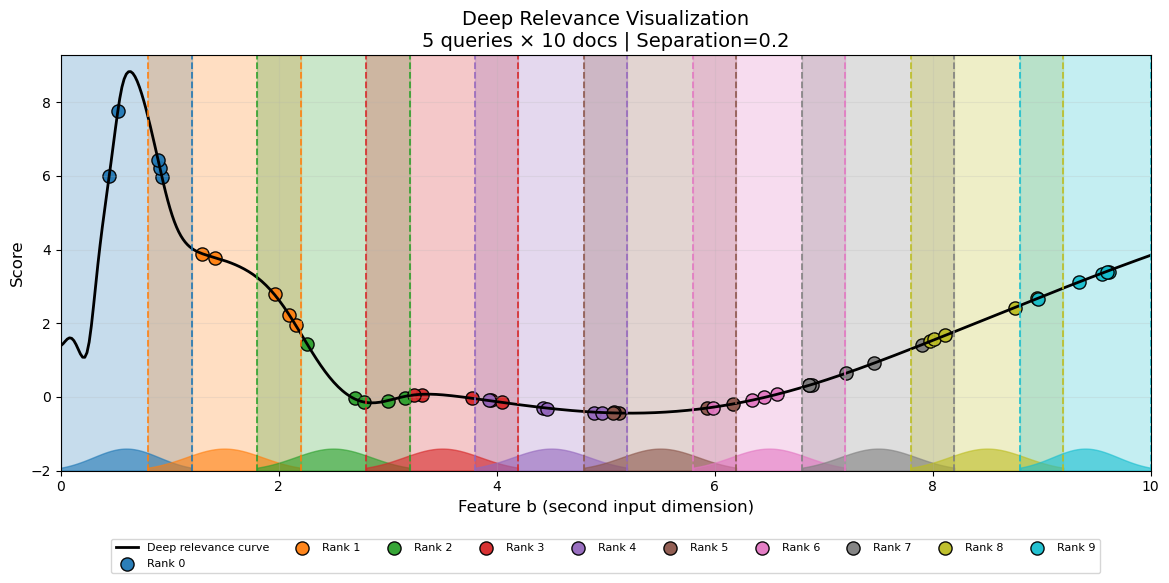

In [135]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# DeepRelevance Model Definition
# -------------------------------
class DeepRelevance:
    def __init__(self, hidden_units=[32, 32, 32], *, random_state: int, noise: float = 0.0):
        self.hidden_units = hidden_units
        self.noise = noise
        self.rng = np.random.default_rng(random_state)
        self.layers = []

    def __call__(self, query_document_features: np.ndarray) -> np.ndarray:
        n_docs, n_features = query_document_features.shape

        if not self.layers:
            input_size = n_features
            for units in self.hidden_units:
                W = self.rng.standard_normal((input_size, units))
                b = self.rng.standard_normal(units)
                self.layers.append((W, b))
                input_size = units

            W_out = self.rng.standard_normal(input_size)
            b_out = self.rng.standard_normal()
            self.output_layer = (W_out, b_out)

        hidden = query_document_features
        for (W, b) in self.layers:
            hidden = np.tanh(hidden.dot(W) + b)

        scores = hidden.dot(self.output_layer[0]) + self.output_layer[1]
        noise = self.noise * self.rng.standard_normal(scores.shape)
        return scores + noise


# ---------------------------------------------
# Data generation function
# ---------------------------------------------
def generate_deep_score_and_features_overlap(num_queries, docs_per_group, s_doc, rng, deep_model):
    all_scores = []
    all_data = []
    boundaries = []

    for qid in range(num_queries):
        begin = 0.0
        end = 1.0
        q_boundaries = []

        for doc_idx in range(docs_per_group):
            a = 0.0
            if doc_idx == 0:
                b = rng.uniform(begin, end + s_doc)
                q_boundaries.append((begin, end + s_doc, doc_idx))
            elif doc_idx == docs_per_group - 1:
                b = rng.uniform(begin - s_doc, end)
                q_boundaries.append((begin - s_doc, end, doc_idx))
            else:
                b = rng.uniform(begin - s_doc, end + s_doc)
                q_boundaries.append((begin - s_doc, end + s_doc, doc_idx))

            features = np.array([[a, b]])
            score = deep_model(features)[0]
            all_scores.append(score)
            all_data.append((qid, doc_idx, [a, b]))

            begin += 1
            end += 1

        boundaries.append(q_boundaries)

    return np.array(all_scores), np.array(all_data, dtype=object), boundaries


# ---------------------------------------------
# Full Visualization Function
# ---------------------------------------------
def visualize_deep_relevance_full(
    num_queries=3,
    docs_per_group=10,
    s_doc=0.2,
    hidden_units=[32, 32, 32],
    noise=0.0,
    random_state=41,
    seed=42,
    fill_cmap="tab10",
    point_cmap="tab10",
    show_fill=True,
    show_boundaries=True,
    jitter=0.0,
):
    rng = np.random.default_rng(seed)
    deep_model = DeepRelevance(hidden_units=hidden_units, random_state=random_state, noise=noise)

    # Generate data
    scores, data, boundaries = generate_deep_score_and_features_overlap(
        num_queries=num_queries,
        docs_per_group=docs_per_group,
        s_doc=s_doc,
        rng=rng,
        deep_model=deep_model,
    )

    doc_ids = np.array([d[1] for d in data])
    b_values = np.array([d[2][1] for d in data])

    # Generate smooth model curve
    a_vals = np.zeros_like(np.linspace(0, 10, 500))
    b_vals = np.linspace(0, 10, 500)
    X_plot = np.column_stack((a_vals, b_vals))
    y_curve = np.ravel(deep_model(X_plot))

    plt.figure(figsize=(12, 6))
    plt.plot(b_vals, y_curve, color='black', lw=2, label='Deep relevance curve')

    # --- Colors ---
    fill_colors = plt.get_cmap(fill_cmap)(np.linspace(0, 1, docs_per_group))
    point_colors = plt.get_cmap(point_cmap)(np.linspace(0, 1, docs_per_group))

    # --- Mean boundaries for each rank ---
    mean_bounds = []
    for doc_idx in range(docs_per_group):
        lefts = [q_bounds[doc_idx][0] for q_bounds in boundaries]
        rights = [q_bounds[doc_idx][1] for q_bounds in boundaries]
        mean_bounds.append((np.mean(lefts), np.mean(rights)))

    # --- Background fill and vertical boundaries ---
    if show_fill or show_boundaries:
        for doc_idx, (left, right) in enumerate(mean_bounds):
            color = fill_colors[doc_idx % len(fill_colors)]
            if show_fill:
                plt.axvspan(left, right, color=color, alpha=0.25)
            if show_boundaries:
                plt.axvline(left, color=color, linestyle='--', linewidth=1.3, alpha=0.9)
                plt.axvline(right, color=color, linestyle='--', linewidth=1.3, alpha=0.9)

    # --- Scatter points ---
    for doc_idx in np.unique(doc_ids):
        mask = doc_ids == doc_idx
        y_vals = scores[mask] + rng.normal(0, jitter, size=np.sum(mask))
        plt.scatter(
            b_values[mask],
            y_vals,
            color=point_colors[doc_idx % len(point_colors)],
            edgecolor='black',
            s=90,
            alpha=0.95,
            label=f"Rank {doc_idx}"
        )

    # --- Mini Gaussian bumps at bottom for each rank ---
    bump_y = -2.0  # vertical position
    bump_scale = 0.6
    x_bump = np.linspace(0, 10, 1000)
    for doc_idx, (left, right) in enumerate(mean_bounds):
        mask = (x_bump >= left) & (x_bump <= right)
        x_region = x_bump[mask]
        if len(x_region) == 0:
            continue
        center = (left + right) / 2
        width = right - left
        gauss = np.exp(-0.5 * ((x_region - center)/(width/4))**2)
        plt.fill_between(
            x_region,
            bump_y,
            bump_y + gauss * bump_scale,
            color=fill_colors[doc_idx % len(fill_colors)],
            alpha=0.6
        )

    plt.xlabel('Feature b (second input dimension)', fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.title(f'Deep Relevance Visualization\n{num_queries} queries × {docs_per_group} docs | Separation={s_doc}', fontsize=14)
    plt.xlim(0, 10)
    plt.ylim(bump_y, max(y_curve)*1.05)
    plt.grid(alpha=0.2)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=10, fontsize=8)
    plt.tight_layout()
    plt.show()

visualize_deep_relevance_full(
num_queries=5,
docs_per_group=10,
s_doc=0.2,
hidden_units=[32, 32, 32],
noise=0.0,
fill_cmap="tab10",
point_cmap="tab10",
jitter=0.02
)



In [41]:
import pandas as pd
with open('results/deep_target_label/data=Custom_dataset_deep,docs_per_group=10,experiment=deep_target_label,logging_policy_ranker=ordered,logging_policy_sampler=e_greedy,num_queries=3,policy_strength=1,policy_temperature=1,random_state=2021,relevance=deep,relevance_tower=deep/test_click_outputs.csv', 'r') as f:
    file = ast.literal_eval(f.read())

In [53]:
np.array(file[-1]["click"]).shape

(392, 10)

In [58]:
from importlib.resources import path
import random

import hydra
import numpy as np
import optax
import pandas as pd
import torch
from flax import config, nnx
from hydra.utils import instantiate
from omegaconf import DictConfig, OmegaConf
from torch.utils.data import DataLoader

from two_tower_confounding.models.towers import *
from two_tower_confounding.metrics import NDCG, MRR, NegativeLogLikelihood
from two_tower_confounding.models.two_tower import TwoTowerModel
from two_tower_confounding.simulation.simulator import Simulator
from two_tower_confounding.trainer import Trainer
from two_tower_confounding.utils import np_collate
import wandb
import os
import orbax.checkpoint as ocp
import flax.serialization as serialization
import jax
from pathlib import Path
import pickle as pkl

In [86]:

def load_model_params(model, ckpt_dir="checkpoint", rng_seed=0):
    """
    Load model parameters into an existing model, keeping RNG separate.
    """
    ckptr = ocp.StandardCheckpointer()
    
    # Split the new model into RNG and other state
    _, _, other_state = nnx.split(model, nnx.RngState, ...)
    
    # Restore saved parameters (other_state)
    ckpt_path = Path(ckpt_dir).resolve()
    restored_other_state = ckptr.restore(ckpt_path, other_state)

    # Merge restored state into the live model
    nnx.update(model, restored_other_state)
    
    print("Relevance tower parameters successfully restored!")
    return model


def load_two_tower_incremental(config, dataset, bias_path="bias.csv", relevance_path="relevance.csv", param_shift=0.0, param_idx=0) -> TwoTowerModel:
    """Rebuild TwoTowerModel and load parameters from CSV files."""

    # 1. Rebuild fresh towers with Hydra
    bias_tower = instantiate(
        config.bias_tower,
        positions=dataset.n_positions,
    )
    relevance_tower = instantiate(
        config.relevance_tower,
        query_doc_features=dataset.n_features,
        query_doc_pairs=dataset.n_documents,
    )

    rngs = nnx.Rngs(config.random_state)
    model = TwoTowerModel(
        bias_tower=bias_tower(rngs=rngs),
        relevance_tower=relevance_tower(rngs=rngs),
        use_propensity_weighting=config.use_propensity_weighting,
    )

    # 2. Load saved CSVs
    bias_df = pd.read_csv(bias_path)
    relevance_df = pd.read_csv(relevance_path)

    bias_values = bias_df["examination"].to_numpy()
    if param_shift != 0.0:
        bias_values[param_idx] += param_shift
        print(f"Shift bias tower {param_idx} parameters by {param_shift:.4f}")

    relevance_values = relevance_df["relevance"].to_numpy()

    # 3. Inject parameters depending on tower type
    # --- Relevance ---
    if isinstance(model.relevance_tower, LinearRelevanceTower):
        print("loading linear relevance params")
        model.relevance_tower.layer.kernel.value = relevance_values.reshape(-1, 1)
    else:
        print("loading deep relevance params")
        model = load_model_params(model, ckpt_dir="checkpoint") 

    # --- Bias ---
    if isinstance(model.bias_tower, EmbeddingBiasTower):
        model.bias_tower.embedding.embedding.value = bias_values.reshape(-1, 1)
    else:
        raise ValueError(f"Unsupported bias tower type: {type(model.bias_tower)}")

    print("Inside tower after shift:", model.bias_tower.embedding.embedding.value[:10])
    print(f"✅ Loaded parameters from {bias_path} and {relevance_path}")
    return model


def train_val_test_datasets(config: DictConfig):
    """
    Simulate clicks on the original train, val, and test datasets of a LTR dataset.
    Note that this should not be used when using embedding towers, as test query-doc pairs
    do not appear during training. To test embedding towers, use the cross-validation method.
    """

    #### LTR Datasets ####
    dataset = instantiate(config.data.dataset)
    preprocessor = instantiate(config.data.preprocessor)

    train_dataset = preprocessor(dataset.load("train"))
    val_dataset = preprocessor(dataset.load("val"))    
    if config.load_test_datasets:
        print("Loading pre-saved test datasets", config.test_dataset_name, config.test_click_dataset_name)
        with open(f"../test_datasets/{config.test_dataset_name}", "rb") as f:
            test_dataset = pkl.load(f)
        with open(f"../test_datasets/{config.test_click_dataset_name}", "rb") as f:
            test_click_dataset = pkl.load(f)
    else:
        test_dataset = preprocessor(dataset.load("test"))

    #### Simulate user clicks ####
    logging_policy_ranker = instantiate(config.logging_policy_ranker)
    logging_policy_ranker.fit(train_dataset)
    logging_policy_sampler = instantiate(config.logging_policy_sampler)

    simulator = Simulator(
        logging_policy_ranker=logging_policy_ranker,
        logging_policy_sampler=logging_policy_sampler,
        bias_strength=config.bias_strength,
        random_state=config.random_state,
    )

    train_click_dataset = simulator(train_dataset, config.train_clicks)
    val_click_dataset = simulator(val_dataset, config.val_clicks)
    if not config.load_test_datasets:
        test_click_dataset = simulator(test_dataset, config.test_clicks)

    return train_click_dataset, val_click_dataset, test_click_dataset, test_dataset


In [112]:
overrides = [
    "experiment=deep_target_label",
    "data=Custom_dataset_deep",
    "relevance=deep",
    "logging_policy_ranker=ordered",
    "relevance_tower=deep",
    "policy_strength=1",
    "policy_temperature=1",
    "random_state=2021",
    "logging_policy_sampler=e_greedy",
    "save_test_datasets=True",
    "load_test_datasets=True",
    "num_queries=3",
    "docs_per_group=10",
    "D=2",
    "label_type=deep_overlap",
    "param_shift=0.0",
    "param_idx=0",
    "single_param=True",
    "freeze_bias_tower=True",
    "test_dataset_name=test_dataset_policy_temperature0.0_num_queries3_.pkl",
    "test_click_dataset_name=test_click_dataset_policy_temperature0.0_num_queries3_.pkl",
]

In [130]:
from hydra.core.global_hydra import GlobalHydra
from hydra import initialize, compose
from omegaconf import OmegaConf

if GlobalHydra.instance().is_initialized():
    GlobalHydra.instance().clear()
# Initialize Hydra without changing working directory
initialize(config_path="config/", version_base="1.3")

# Compose config
config = compose(config_name="config", overrides=overrides)

# Print config
print(OmegaConf.to_yaml(config))

random.seed(config.random_state)
np.random.seed(config.random_state)
torch.manual_seed(config.random_state)


train_click_dataset, val_click_dataset, test_click_dataset, test_dataset = (
    train_val_test_datasets(config)
)

train_click_loader = DataLoader(
    train_click_dataset,
    batch_size=512,
    collate_fn=np_collate,
    shuffle=True,
)
val_click_loader = DataLoader(
    val_click_dataset,
    batch_size=512,
    collate_fn=np_collate,
)
test_click_loader = DataLoader(
    test_click_dataset,
    batch_size=512,
    collate_fn=np_collate,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=512,
    collate_fn=np_collate,
)

dataset_dir: ~/Documents/Uni/Project_AI/ltr_datasets
experiment: deep_target_label
random_state: 2021
use_cross_validation: false
sample_queries: null
features: all
relevance: deep
relevance_noise: 0.0
relevance_quantization: false
train_clicks: 50000
val_clicks: 5000
test_clicks: 5000
policy_strength: 1
policy_temperature: 1
bias_strength: 1.0
param_shift: 0.0
use_propensity_weighting: false
freeze_bias_tower: true
single_param: true
param_idx: 0
save_test_datasets: true
load_test_datasets: true
test_dataset_name: test_dataset_policy_temperature0.0_num_queries3_.pkl
test_click_dataset_name: test_click_dataset_policy_temperature0.0_num_queries3_.pkl
num_groups: 1
docs_per_group: 10
D: 2
s_group: 0.0
s_doc: 0.5
num_queries: 3
label_type: deep_overlap
data:
  dataset:
    _target_: two_tower_confounding.data.datasets.custom.CustomDatasetDeep
    base_dir: ${dataset_dir}
    num_groups: ${num_groups}
    docs_per_group: ${docs_per_group}
    D: ${D}
    s_group: ${s_group}
    s_doc: ${s_

Simulating clicks..: 100%|██████████| 5000/5000 [00:00<00:00, 61070.24it/s]


In [132]:
model = load_two_tower_incremental(config, test_dataset, bias_path="bias.csv", relevance_path="relevance.csv", param_shift=config.param_shift, param_idx=config.param_idx)

loading deep relevance params
Relevance tower parameters successfully restored!
Inside tower after shift: [[ 0.        ]
 [-0.67833436]
 [-1.0700296 ]
 [-1.3715822 ]
 [-1.4812343 ]
 [-1.8197137 ]
 [-1.9672043 ]
 [-2.082634  ]
 [-2.211564  ]
 [-2.0615923 ]]
✅ Loaded parameters from bias.csv and relevance.csv


In [ ]:
model

{'dataset_dir': '~/Documents/Uni/Project_AI/ltr_datasets', 'experiment': 'deep_target_label', 'random_state': 2021, 'use_cross_validation': False, 'sample_queries': None, 'features': 'all', 'relevance': 'deep', 'relevance_noise': 0.0, 'relevance_quantization': False, 'train_clicks': 50000, 'val_clicks': 5000, 'test_clicks': 5000, 'policy_strength': 1, 'policy_temperature': 1, 'bias_strength': 1.0, 'param_shift': 0.0, 'use_propensity_weighting': False, 'freeze_bias_tower': True, 'single_param': True, 'param_idx': 0, 'save_test_datasets': True, 'load_test_datasets': True, 'test_dataset_name': 'test_dataset_policy_temperature0.0_num_queries3_.pkl', 'test_click_dataset_name': 'test_click_dataset_policy_temperature0.0_num_queries3_.pkl', 'num_groups': 1, 'docs_per_group': 25, 'D': 2, 's_group': 0.0, 's_doc': 0.5, 'num_queries': 3, 'label_type': 'deep_overlap', 'data': {'dataset': {'_target_': 'two_tower_confounding.data.datasets.custom.CustomDatasetDeep', 'base_dir': '${dataset_dir}', 'num_

In [133]:
print(model.relevance_tower)

# Check bias tower
print(model.bias_tower)

DeepRelevanceTower(
  modules=[Linear(
    kernel=Param(
      value=Array(shape=(2, 32), dtype=float32)
    ),
    bias=Param(
      value=Array(shape=(32,), dtype=float32)
    ),
    in_features=2,
    out_features=32,
    use_bias=True,
    dtype=None,
    param_dtype=<class 'jax.numpy.float32'>,
    precision=None,
    kernel_init=<function variance_scaling.<locals>.init at 0x169846d40>,
    bias_init=<function zeros at 0x16ac9c160>,
    dot_general=<function dot_general at 0x11b3f85e0>
  ), <PjitFunction of <function elu at 0x16ac1aef0>>, Dropout(rate=0, broadcast_dims=(), deterministic=False, rng_collection='dropout', rngs=Rngs(
    default=RngStream(
      key=RngKey(
        value=Array((), dtype=key<fry>) overlaying:
        [   0 2021],
        tag='default'
      ),
      count=RngCount(
        value=Array(7, dtype=uint32),
        tag='default'
      )
    )
  )), Linear(
    kernel=Param(
      value=Array(shape=(32, 32), dtype=float32)
    ),
    bias=Param(
      value=

In [156]:
import jax.numpy as jnp

num_positions = 10
num_samples = 1000
feature_dim = 2  # matches DeepRelevanceTower input

# 100 samples for the second feature
sample_values = jnp.linspace(0.0, 10.0, num_samples)

# repeat for all positions
query_doc_features = jnp.zeros((num_positions * num_samples, feature_dim))
query_doc_features = query_doc_features.at[:, 1].set(jnp.tile(sample_values, num_positions))

# repeat positions for each sample
positions = jnp.repeat(jnp.arange(num_positions), num_samples)

batch = {
    "query_doc_features": query_doc_features,  # shape [1000,2]
    "positions": positions,                    # shape [1000]
    "clicks": jnp.zeros(num_positions * num_samples),
    "mask": jnp.ones(num_positions * num_samples),
    "propensities": jnp.ones(num_positions * num_samples)
}


In [157]:
model.eval()
output = model(batch)


In [158]:
import pandas as pd

df = pd.DataFrame({
    "position": positions,
    "input_feature": jnp.tile(sample_values, num_positions),
    "relevance": jnp.ravel(output.relevance),
    "examination": jnp.ravel(output.examination),
    "click": jnp.ravel(output.click)
})

print(df)


      position  input_feature  relevance  examination      click
0            0       0.000000  -2.823698     0.000000  -2.823698
1            0       0.010010  -2.802958     0.000000  -2.802958
2            0       0.020020  -2.782298     0.000000  -2.782298
3            0       0.030030  -2.761720     0.000000  -2.761720
4            0       0.040040  -2.741223     0.000000  -2.741223
...        ...            ...        ...          ...        ...
9995         9       9.959960 -15.712673    -2.061592 -17.774265
9996         9       9.969970 -15.723393    -2.061592 -17.784986
9997         9       9.979980 -15.734110    -2.061592 -17.795702
9998         9       9.989989 -15.744829    -2.061592 -17.806421
9999         9      10.000000 -15.755548    -2.061592 -17.817141

[10000 rows x 5 columns]


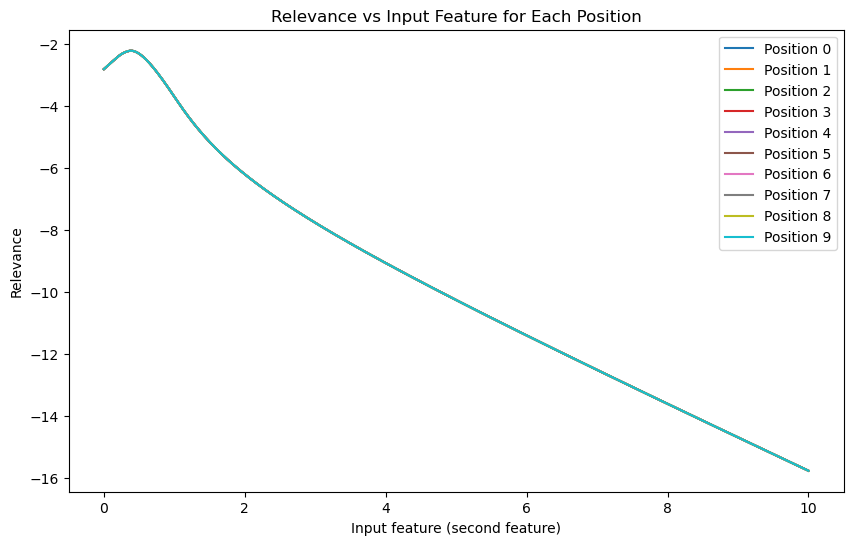

In [159]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for pos in range(10):
    subset = df[df["position"] == pos]
    plt.plot(subset["input_feature"], subset["relevance"], label=f"Position {pos}")

plt.xlabel("Input feature (second feature)")
plt.ylabel("Relevance")
plt.title("Relevance vs Input Feature for Each Position")
plt.legend()
plt.show()